# Sparse Connectivity Prediction with LASSO

Predict each functional connection from structural network features using LASSO, compare prediction errors with a direct-connection baseline, and inspect selected features.

Run this notebook from the project root. See the [project overview](README.md) for the full analysis workflow.


## LASSO Regression

For each functional edge, a LASSO model was fitted using each unique structural connection (upper triangle in the matrix) as features. Performance was evaluated using nested leave-one-subject-out cross-validation. For each of the 19 outer folds, the held-out subject was excluded from scaling, parameter selection, and fitting. The remaining 18 subjects were used in an inner 5-fold cross-validation to select the regularisation parameter $\alpha$. Each inner training fold fitted its own standardisation (0 mean, unit variance).

The candidate grid contains 50 logarithmically spaced alpha values from $10^{-5}$ to $1$, fixed before examining the data. After selection, scaling and fitting were repeated on the 18 outer training subjects and used to predict the held-out subject. All 2,278 connections use the same outer subject splits.

The baseline uses only the direct structural connection $s_{ij}$. When that predictor is constant within a training fold, its prediction is the training subjects' mean functional connectivity. A separate full-data refit supplies the feature-selection plots; these fits are not used to calculate prediction errors.

The implementation is in [scripts/lasso_evaluation.py](scripts/lasso_evaluation.py). It evaluates the LASSO regularisation path efficiently, with coordinate descent as a checked fallback for numerically degenerate paths.

In [1]:
from pathlib import Path
figure_dir = Path("figures/lasso_connectivity_prediction")
figure_dir.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scripts.lasso_evaluation import (
    ALPHAS, direct_ols_predictions, nested_lasso_predictions, fit_descriptive_model,
)
from sklearn.metrics import mean_squared_error

base_path = "data/connectomes/"

def load_connectome(path):
    comments = []
    with open(path) as f:
        for line in f:
            if line.startswith("#"):
                comments.append(line.strip())
            else:
                break
    names = None
    for c in comments:
        if c.lower().startswith("# name:"):
            names = [x.strip() for x in c.split(":", 1)[1].split(",")]
    df = pd.read_csv(path, header=None, comment="#")
    if names is not None and len(names) == df.shape[0]:
        df.index = names
        df.columns = names
    return df

structural, functional = {}, {}
for pid in range(32, 51):
    structural[pid] = load_connectome(f"{base_path}{pid}_WFA_68.csv")
    functional[pid] = load_connectome(f"{base_path}{pid}_rsfMRI_68.csv")

subjects  = sorted(structural.keys())
n_subj    = len(subjects)
n_regions = structural[subjects[0]].shape[0]
print(f"Loaded {n_subj} subjects, {n_regions} regions.")

Loaded 19 subjects, 68 regions.


In [2]:
mask_upper  = np.triu(np.ones((n_regions, n_regions), dtype=bool), k=1)
edge_pairs  = list(zip(*np.where(mask_upper)))   # list of (i, j) tuples
n_edges     = len(edge_pairs)
regions     = structural[subjects[0]].index.tolist()

# Structural feature matrix and functional target matrix
X_struct = np.zeros((n_subj, n_edges), dtype=np.float64)
F_mat    = np.zeros((n_subj, n_edges), dtype=np.float64)

for s_idx, pid in enumerate(subjects):
    X_struct[s_idx] = structural[pid].values[mask_upper]
    F_mat[s_idx]    = functional[pid].values[mask_upper]

# Keep raw features here. Scaling is fitted separately inside every training fold.
print(f"Feature matrix X: {X_struct.shape} (subjects x structural edges)")
print(f"Target matrix F: {F_mat.shape} (subjects x functional edges)")

# Also flag which edges have any structural connectivity across subjects
struct_present = (X_struct > 0).sum(axis=0)
print(f"\nStructural edges present in ≥10/19 subjects: {(struct_present >= 10).sum()}")
print(f"Structural edges present in ≥1 subject:      {(struct_present >= 1).sum()}")

Feature matrix X: (19, 2278) (subjects x structural edges)
Target matrix F: (19, 2278) (subjects x functional edges)

Structural edges present in ≥10/19 subjects: 803
Structural edges present in ≥1 subject:      1522


In [3]:
# Evaluate every edge on the same 19 held-out subjects.
ols_predictions = np.column_stack([
    direct_ols_predictions(X_struct[:, idx], F_mat[:, idx])
    for idx in range(n_edges)
])
ols_mse = np.mean((F_mat - ols_predictions) ** 2, axis=0)
print(f"OLS LOOCV MSE - mean: {ols_mse.mean():.6f} median: {np.median(ols_mse):.6f}")


OLS LOOCV MSE - mean: 0.003482 median: 0.003167


In [4]:
import os
from joblib import Parallel, delayed, parallel_config


def fit_lasso_edge(idx):
    y = F_mat[:, idx]
    predictions, fold_alphas, fallbacks = nested_lasso_predictions(X_struct, y)
    # This separate refit is descriptive; it never supplies held-out predictions.
    alpha, coefficients, refit_fallbacks = fit_descriptive_model(X_struct, y)
    selected = np.flatnonzero(np.abs(coefficients) > 1e-10)
    return idx, predictions, fold_alphas, alpha, selected, fallbacks + refit_fallbacks


lasso_predictions = np.full_like(F_mat, np.nan)
lasso_fold_alphas = np.full_like(F_mat, np.nan)
lasso_alpha = np.zeros(n_edges)
lasso_n_selected = np.zeros(n_edges, dtype=int)
selected_features = [None] * n_edges
solver_fallbacks = np.zeros(n_edges, dtype=int)

workers = min(6, os.cpu_count() or 1)
with parallel_config(backend="loky", n_jobs=workers, inner_max_num_threads=1):
    results = Parallel(return_as="generator_unordered")(
        delayed(fit_lasso_edge)(idx) for idx in range(n_edges)
    )
    for completed, result in enumerate(results, start=1):
        idx, predictions, fold_alphas, alpha, selected, fallbacks = result
        lasso_predictions[:, idx] = predictions
        lasso_fold_alphas[:, idx] = fold_alphas
        lasso_alpha[idx] = alpha
        lasso_n_selected[idx] = len(selected)
        selected_features[idx] = selected
        solver_fallbacks[idx] = fallbacks
        if completed % 100 == 0 or completed == n_edges:
            print(f"Completed {completed}/{n_edges} nested evaluations", flush=True)

assert np.isfinite(lasso_predictions).all()
lasso_mse = np.mean((F_mat - lasso_predictions) ** 2, axis=0)
print(f"Nested LASSO LOOCV MSE - mean: {lasso_mse.mean():.6f} median: {np.median(lasso_mse):.6f}")
print(f"Numerical path fallbacks to coordinate descent: {solver_fallbacks.sum()}")


Completed 100/2278 nested evaluations


Completed 200/2278 nested evaluations


Completed 300/2278 nested evaluations


Completed 400/2278 nested evaluations


Completed 500/2278 nested evaluations


...

Completed 2000/2278 nested evaluations


Completed 2100/2278 nested evaluations


Completed 2200/2278 nested evaluations


Completed 2278/2278 nested evaluations


Nested LASSO LOOCV MSE - mean: 0.003524 median: 0.003227
Numerical path fallbacks to coordinate descent: 15478


In [5]:
improvement = ols_mse - lasso_mse          # positive = LASSO better
pct_better  = (improvement / ols_mse) * 100

print("=" * 55)
print(f"{'Model':<20} {'Mean MSE':>10} {'Median MSE':>12}")
print("-" * 55)
print(f"{'OLS (f ~ s_ij)':<20} {ols_mse.mean():>10.6f} {np.median(ols_mse):>12.6f}")
print(f"{'LASSO':<20} {lasso_mse.mean():>10.6f} {np.median(lasso_mse):>12.6f}")
print("=" * 55)
print(f"\nEdges where LASSO < OLS:  {(improvement > 0).sum()} / {n_edges}  ({(improvement>0).mean()*100:.1f}%)")
print(f"Mean improvement:          {pct_better.mean():.2f}%")
print(f"Median improvement:        {np.median(pct_better):.2f}%")

# Summary table
summary = pd.DataFrame({
    "Model":      ["OLS (f ~ s_ij)", "LASSO (all structural features)"],
    "Mean MSE":   [ols_mse.mean(),   lasso_mse.mean()],
    "Median MSE": [np.median(ols_mse), np.median(lasso_mse)],
    "Std MSE":    [ols_mse.std(),    lasso_mse.std()],
})
print("\n", summary.round(6).to_string(index=False))

Model                  Mean MSE   Median MSE
-------------------------------------------------------
OLS (f ~ s_ij)         0.003482     0.003167
LASSO                  0.003524     0.003227

Edges where LASSO < OLS:  932 / 2278  (40.9%)
Mean improvement:          -3.47%
Median improvement:        -1.82%

                           Model  Mean MSE  Median MSE  Std MSE
                 OLS (f ~ s_ij)  0.003482    0.003167 0.001719
LASSO (all structural features)  0.003524    0.003227 0.001691


**Table 6:** LASSO vs OLS baseline (LOOCV MSE across all 2278 functional edges). LASSO uses nested tuning; the OLS baseline uses only the direct structural connection $s_{ij}$.

| Model | Mean MSE | Median MSE | SD MSE |
| --- | --- | --- | --- |
| OLS ($f_{ij}=\alpha_{ij}+\beta_{ij}s_{ij}$) | 0.003482 | 0.003167 | 0.001719 |
| LASSO (all 2278 structural features) | 0.003524 | 0.003227 | 0.001691 |

**Evaluation update:** The original non-nested scores have been replaced with fully nested predictions. Scaling is fitted on the training partition in both the inner and outer folds. Parameter selection never sees the outer test subject; constant-predictor baselines also use training data only.

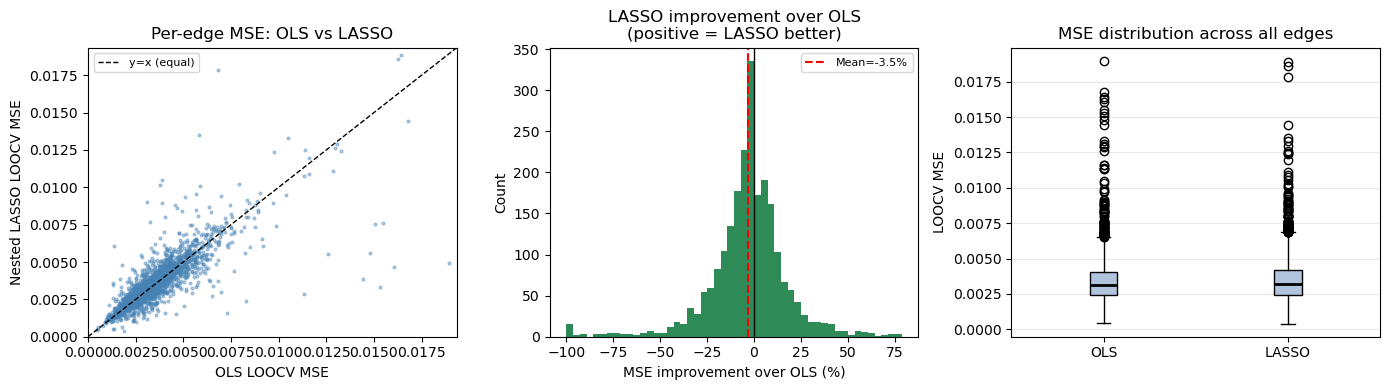

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. MSE scatter: OLS vs LASSO per edge
ax = axes[0]
ax.scatter(ols_mse, lasso_mse, s=4, alpha=0.4, color="steelblue")
lim = max(ols_mse.max(), lasso_mse.max()) * 1.02
ax.plot([0, lim], [0, lim], "k--", linewidth=1, label="y=x (equal)")
ax.set_xlabel("OLS LOOCV MSE")
ax.set_ylabel("Nested LASSO LOOCV MSE")
ax.set_title("Per-edge MSE: OLS vs LASSO")
ax.legend(fontsize=8)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)

# 2. Distribution of % improvement
ax = axes[1]
ax.hist(np.clip(pct_better, -100, 100), bins=50, color="seagreen", edgecolor="none")
ax.axvline(0, color="black", linewidth=1)
ax.axvline(pct_better.mean(), color="red", linestyle="--", label=f"Mean={pct_better.mean():.1f}%")
ax.set_xlabel("MSE improvement over OLS (%)")
ax.set_ylabel("Count")
ax.set_title("LASSO improvement over OLS\n(positive = LASSO better)")
ax.legend(fontsize=8)

# 3. Boxplot side-by-side
ax = axes[2]
ax.boxplot([ols_mse, lasso_mse], tick_labels=["OLS", "LASSO"],
           patch_artist=True,
           boxprops=dict(facecolor="lightsteelblue"),
           medianprops=dict(color="black", linewidth=2))
ax.set_ylabel("LOOCV MSE")
ax.set_title("MSE distribution across all edges")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(str(figure_dir / 'lasso_vs_ols.png'), dpi=180, bbox_inches="tight")
plt.show()

**Figure 5:** Per-edge LOOCV MSE: OLS vs LASSO scatter (left), distribution of proportional improvement (centre), and side-by-side boxplot (right). Points below the diagonal indicate edges where LASSO outperforms OLS.

## LASSO-based Prediction

LASSO achieves a lower mean LOOCV MSE than the linear model in 40.9% of the edges, with a mean and median improvement of -3.5% and -1.8% respectively. These negative improvements mean that errors increase on average. The overall mean MSE is 0.003524 for LASSO compared with 0.003482 for OLS, an increase of 1.2%. This percentage compares the aggregate mean errors; the mean improvement above averages the percentage change separately for each edge.

The variance of MSE across edges also decreases slightly under LASSO, but this does not establish more stable predictions across subjects. The corrected nested evaluation does not show an overall predictive advantage for LASSO over the direct-connection baseline.

Features selected per functional edge (full-data descriptive refits):
  Mean:    3.25
  Median:  0.0
  Min/Max: 0 / 36
  Edges with 0 selected: 1335 (58.6%)


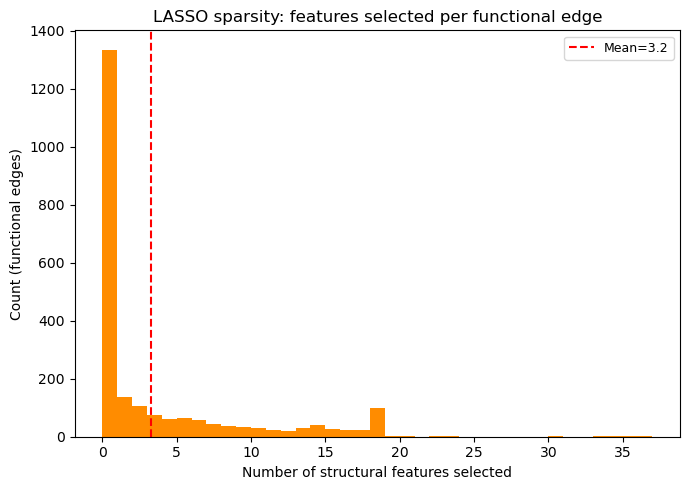

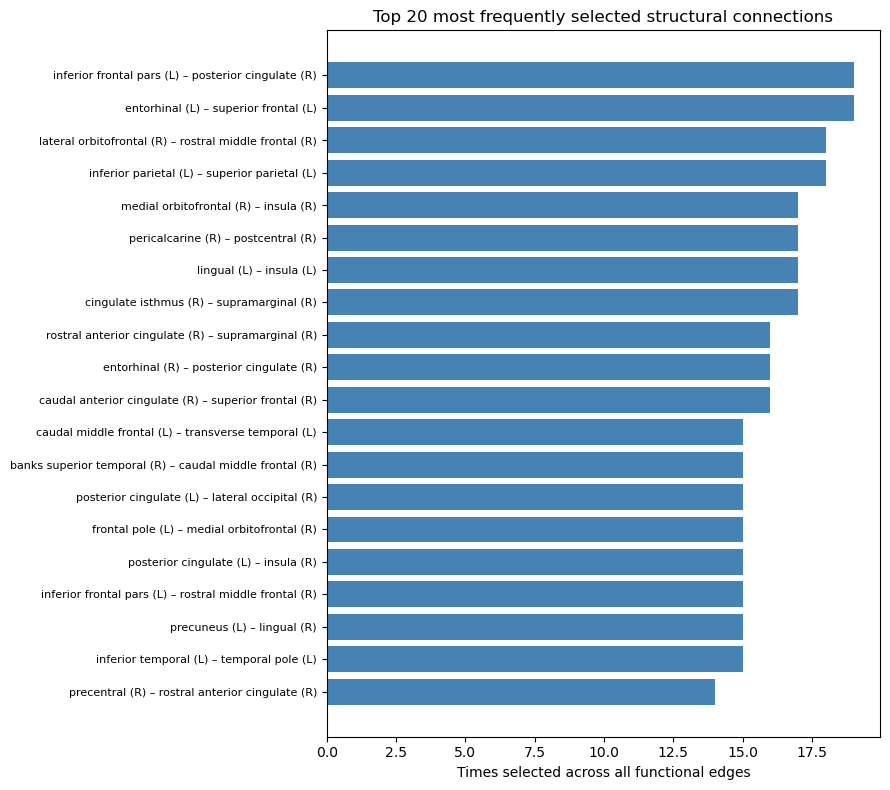

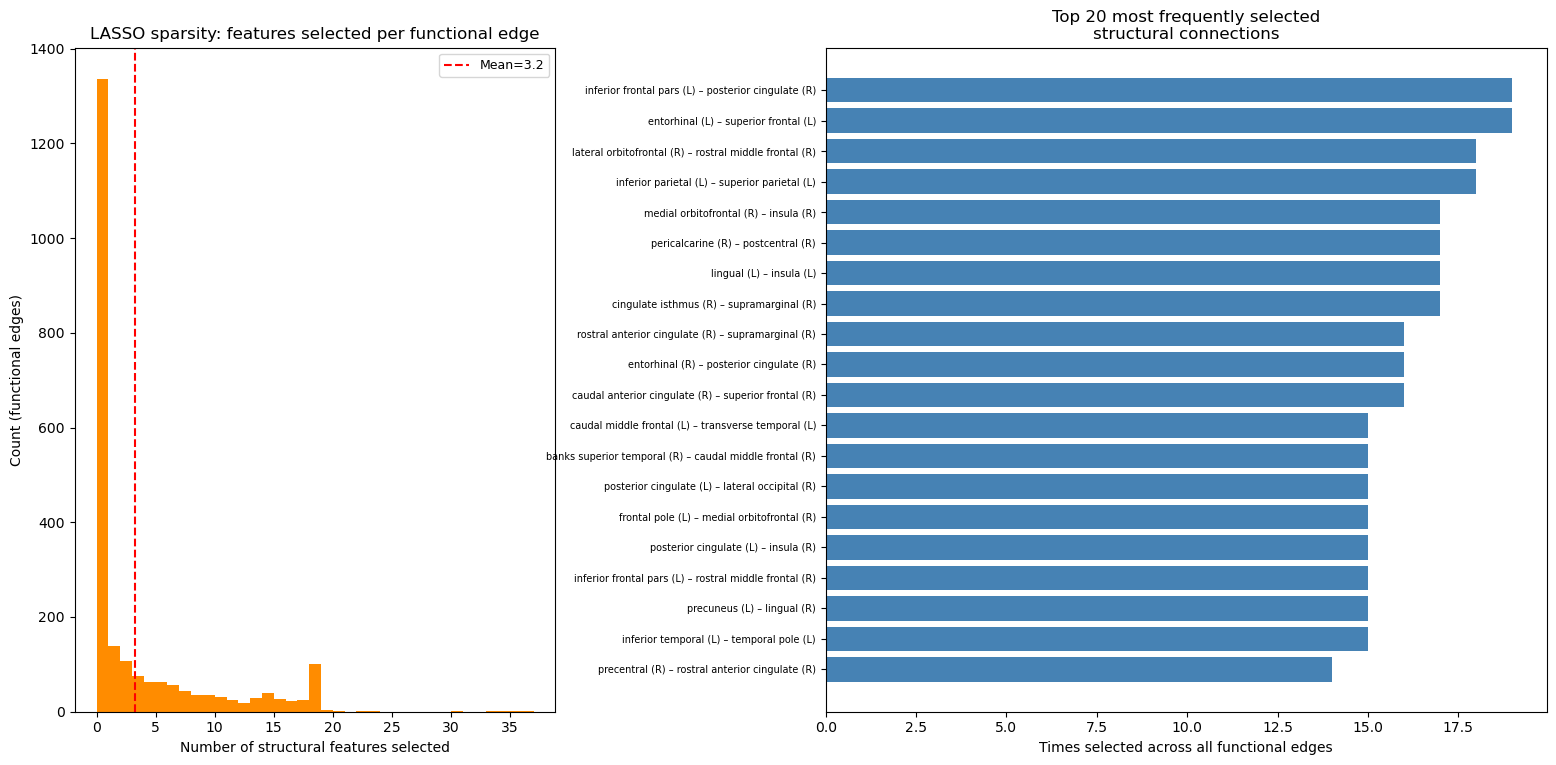

In [7]:
def short_label(name):
    hemi = "(L)" if name.endswith("_left") else ("(R)" if name.endswith("_right") else "")
    stem = name.replace("_left","").replace("_right","")
    parts = [p for p in stem.split("_") if p not in {"gyrus","cortex","sulcus"}]
    return " ".join(parts[:3]) + (" " + hemi if hemi else "")

print(f"Features selected per functional edge (full-data descriptive refits):")
print(f"  Mean:    {lasso_n_selected.mean():.2f}")
print(f"  Median:  {np.median(lasso_n_selected):.1f}")
print(f"  Min/Max: {lasso_n_selected.min()} / {lasso_n_selected.max()}")
print(f"  Edges with 0 selected: {(lasso_n_selected == 0).sum()} ({(lasso_n_selected==0).mean()*100:.1f}%)")

# How often is each structural edge selected — top 20
selection_counts = np.zeros(n_edges, dtype=int)
for feats in selected_features:
    if feats is not None and len(feats) > 0:
        selection_counts[feats] += 1

top20_idx    = np.argsort(selection_counts)[::-1][:20]
top20_counts = selection_counts[top20_idx]
top20_labels = [f"{short_label(regions[edge_pairs[k][0]])} – {short_label(regions[edge_pairs[k][1]])}"
                for k in top20_idx]

# ── Left plot: histogram ──────────────────────────────────────────────────────
fig1, ax0 = plt.subplots(figsize=(7, 5))
ax0.hist(lasso_n_selected, bins=range(0, lasso_n_selected.max()+2), color="darkorange", edgecolor="none")
ax0.axvline(lasso_n_selected.mean(), color="red", linestyle="--",
            label=f"Mean={lasso_n_selected.mean():.1f}")
ax0.set_xlabel("Number of structural features selected")
ax0.set_ylabel("Count (functional edges)")
ax0.set_title("LASSO sparsity: features selected per functional edge")
ax0.legend(fontsize=9)
fig1.tight_layout()
fig1.savefig(str(figure_dir / 'sparsity.png'), dpi=180, bbox_inches="tight")
plt.show()

# ── Right plot: bar chart ─────────────────────────────────────────────────────
fig2, ax1 = plt.subplots(figsize=(9, 8))
ax1.barh(range(20), top20_counts[::-1], color="steelblue")
ax1.set_yticks(range(20))
ax1.set_yticklabels(top20_labels[::-1], fontsize=8)
ax1.set_xlabel("Times selected across all functional edges")
ax1.set_title("Top 20 most frequently selected structural connections")
fig2.tight_layout()
fig2.savefig(str(figure_dir / 'top20.png'), dpi=180, bbox_inches="tight")
plt.show()

# ── Combined (for report) ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8),
                         gridspec_kw={"width_ratios": [1, 1.5]})
axes[0].hist(lasso_n_selected, bins=range(0, lasso_n_selected.max()+2),
             color="darkorange", edgecolor="none")
axes[0].axvline(lasso_n_selected.mean(), color="red", linestyle="--",
                label=f"Mean={lasso_n_selected.mean():.1f}")
axes[0].set_xlabel("Number of structural features selected")
axes[0].set_ylabel("Count (functional edges)")
axes[0].set_title("LASSO sparsity: features selected per functional edge")
axes[0].legend(fontsize=9)

axes[1].barh(range(20), top20_counts[::-1], color="steelblue")
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(top20_labels[::-1], fontsize=7)
axes[1].set_xlabel("Times selected across all functional edges")
axes[1].set_title("Top 20 most frequently selected\nstructural connections")

fig.subplots_adjust(left=0.06, right=0.98, top=0.93, bottom=0.10, wspace=0.45)
fig.savefig(str(figure_dir / 'feature_selection.png'), dpi=180, bbox_inches="tight")
plt.show()

**Figure 6:** LASSO feature selection from separate full-data descriptive refits. Left: histogram of number of structural features selected per functional edge (mean = 3.2, median = 0; 58.6% select zero features). Right: 20 most frequently selected structural connections across all functional edges, including connections involving the posterior cingulate, cingulate isthmus, insula, and rostral middle frontal regions. These frequencies do not measure selection stability across outer validation folds.

Edges with at least one structural connection: 1522
  LASSO selected the direct s_ij:          2 (0.1%)
  LASSO did NOT select the direct s_ij:    1520 (99.9%)
Edges with no structural connection at all: 756


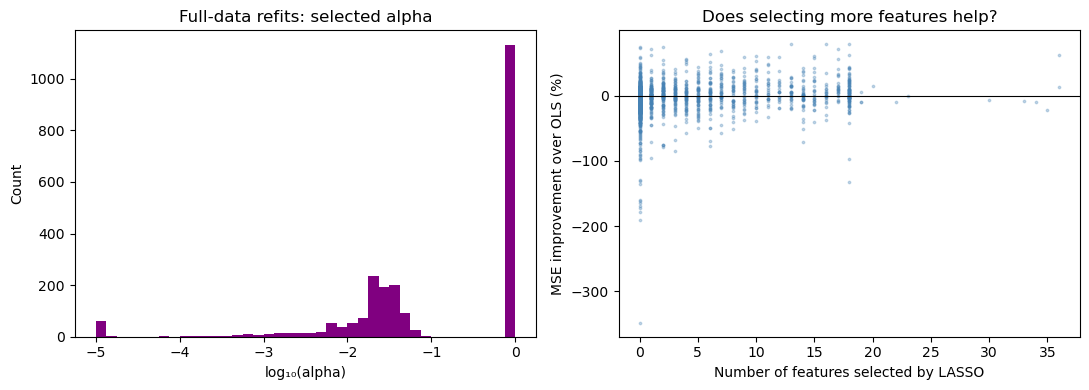

Saved held-out predictions, per-edge metrics and summary to results/.


In [8]:
has_direct_struct = struct_present > 0    # edges present in ≥1 subject

direct_selected   = 0
direct_not_selected = 0
no_struct_at_all  = 0

for idx, feats in enumerate(selected_features):
    if not has_direct_struct[idx]:
        no_struct_at_all += 1
        continue
    if feats is not None and idx in feats:
        direct_selected += 1
    else:
        direct_not_selected += 1

total_with_struct = direct_selected + direct_not_selected
print(f"Edges with at least one structural connection: {total_with_struct}")
print(f"  LASSO selected the direct s_ij:          {direct_selected} ({direct_selected/total_with_struct*100:.1f}%)")
print(f"  LASSO did NOT select the direct s_ij:    {direct_not_selected} ({direct_not_selected/total_with_struct*100:.1f}%)")
print(f"Edges with no structural connection at all: {no_struct_at_all}")

# Alpha distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(np.log10(lasso_alpha + 1e-10), bins=40, color="purple", edgecolor="none")
axes[0].set_xlabel("log₁₀(alpha)")
axes[0].set_ylabel("Count")
axes[0].set_title("Full-data refits: selected alpha")

# MSE improvement vs n_selected
axes[1].scatter(lasso_n_selected, pct_better, s=3, alpha=0.3, color="steelblue")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Number of features selected by LASSO")
axes[1].set_ylabel("MSE improvement over OLS (%)")
axes[1].set_title("Does selecting more features help?")

plt.tight_layout()
plt.savefig(str(figure_dir / 'alpha_and_nfeatures.png'), dpi=180, bbox_inches="tight")
plt.show()

# Save the actual held-out predictions and fold-specific tuning choices.
import json
result_dir = Path("results")
result_dir.mkdir(exist_ok=True)
np.savez_compressed(
    result_dir / "lasso_nested_predictions.npz",
    subjects=np.array(subjects), edge_pairs=np.array(edge_pairs),
    observed=F_mat, ols_predictions=ols_predictions,
    lasso_predictions=lasso_predictions, outer_alphas=lasso_fold_alphas,
    alpha_grid=ALPHAS,
)
metrics = pd.DataFrame({
    "region_i": [regions[i] for i, j in edge_pairs],
    "region_j": [regions[j] for i, j in edge_pairs],
    "ols_mse": ols_mse, "lasso_nested_mse": lasso_mse,
    "improvement_percent": pct_better,
    "full_refit_alpha": lasso_alpha,
    "full_refit_feature_count": lasso_n_selected,
})
metrics.to_csv(result_dir / "lasso_edge_metrics.csv", index=False)
summary_record = {
    "protocol": "Outer leave-one-subject-out; inner 5-fold CV with fold-local scaling",
    "alpha_grid": ALPHAS.tolist(), "inner_shuffle_seed": 0,
    "n_subjects": n_subj, "n_edges": n_edges,
    "ols_mean_mse": float(ols_mse.mean()),
    "ols_median_mse": float(np.median(ols_mse)),
    "ols_std_mse": float(ols_mse.std()),
    "lasso_mean_mse": float(lasso_mse.mean()),
    "lasso_median_mse": float(np.median(lasso_mse)),
    "lasso_std_mse": float(lasso_mse.std()),
    "percent_edges_better": float((improvement > 0).mean() * 100),
    "mean_improvement_percent": float(pct_better.mean()),
    "median_improvement_percent": float(np.median(pct_better)),
    "full_refit_mean_features": float(lasso_n_selected.mean()),
    "full_refit_median_features": float(np.median(lasso_n_selected)),
    "full_refit_zero_features_percent": float((lasso_n_selected == 0).mean() * 100),
    "direct_edges_present": int(total_with_struct),
    "full_refit_direct_selected": int(direct_selected),
    "full_refit_direct_selected_percent": float(direct_selected / total_with_struct * 100),
    "solver_fallbacks": int(solver_fallbacks.sum()),
}
(result_dir / "lasso_summary.json").write_text(json.dumps(summary_record, indent=2) + "\n")
print("Saved held-out predictions, per-edge metrics and summary to results/.")


## Structural Feature Selection

The median number of structural features selected per functional edge is 0, and 58.6% of functional edges select zero features. Out of 1522 functional edges that have a structural connection in at least one subject, LASSO selects the direct structrual connection in only 0.1% of the cases (2 edges). These counts describe the separate full-data refits. The selected features are mostly other structural connections, but this does not establish that shared ’hubs’ explain functional connectivity better than direct connections. The nested prediction results do not show an overall advantage for the larger feature set.

## Conclusion

This report explored the structural-functional connectivity relationship, where we explored the connectomes as a function of threshold parameters, and modelled functional connectivity from structural connectivity using regression.

Core Task 1 shows that FA thresholding acts as a tissue-type filter, with structural graph properties best shown at FA = 0.2−0.3. Functional connectome estimation required shrinkage regularisation given that the sample has far fewer time points than regions. Core Task 2 showed that the structural-functional relationship is weak and broadly linear at the per edge level (around 7% variance explained), with indirect two-step connectivity matching or slightly outperforming direct connections by both AIC and LOOCV SSE. This suggests that the presence of some structural route between two regions matters more than the specific path when predicting a functional connection. Across subjects, global linear models generalised surprisingly well, which shows a stable structural-functional relationship between different individuals. In the full-data LASSO refits, the direct structural connection was selected in only 0.1% of functional edges with an observed direct connection. Nested evaluation did not show an overall predictive advantage over the direct-connection baseline.

Several limitations should be considered in this project. The small sample size of 19 subjects heavily limits the statistical power of the results. All functional connectivity was estimated from resting-state data. An interesting extension of this project could be to explore the structural-functional relationship with task-evoked functional connectivity. Nevertheless, these findings show that structural white matter connectivity is a weak predictor of resting state functional connectivity, and that the structural connectome acts more as a scaffold for functional connections, where functional connectivity shows dynamics that are not captured by static anatomy alone.

**Verification note:** The approximately 7% explained variance in the original conclusion refers to the subject-specific global models, not a measured average across per-edge regressions. Feature-selection summaries describe full-data refits, rather than features independently validated in every outer fold.